In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


In [ ]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/BTL_hocmay/train.csv')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59381 entries, 0 to 59380
Columns: 128 entries, Id to Response
dtypes: float64(18), int64(109), object(1)
memory usage: 58.0+ MB


In [ ]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Ratio': df.isnull().mean().values
}).sort_values(by='Missing_Ratio', ascending=False)

missing_df.head(20)

,Column,Missing_Count,Missing_Ratio
47,Medical_History_10,58824,0.990620
69,Medical_History_32,58274,0.981358
61,Medical_History_24,55580,0.935990
52,Medical_History_15,44596,0.751015
37,Family_Hist_5,41811,0.704114
35,Family_Hist_3,34241,0.576632
34,Family_Hist_2,28656,0.482579
29,Insurance_History_5,25396,0.427679
36,Family_Hist_4,19184,0.323066
17,Employment_Info_6,10854,0.182786


## 4. Tạo nhãn phân loại nhị phân

Risk = 1 nếu Response >= 7

Risk = 0 nếu Response < 7


In [ ]:

# Kiểm tra phân phối Response ban đầu
print("Phân phối Response:")
print(df["Response"].value_counts().sort_index())

# Thử các ngưỡng từ 2 đến 8
balance_results = []

for threshold in range(2, 9):
    temp_risk = (df["Response"] >= threshold).astype(int)

    count_0 = (temp_risk == 0).sum()
    count_1 = (temp_risk == 1).sum()
    total = len(temp_risk)

    ratio_0 = count_0 / total
    ratio_1 = count_1 / total

    # Độ lệch càng nhỏ thì càng cân bằng
    balance_gap = abs(ratio_0 - ratio_1)

    balance_results.append({
        "Điều kiện": f"Risk = 1 nếu Response >= {threshold}",
        "Threshold": threshold,
        "Số mẫu Risk=0": count_0,
        "Số mẫu Risk=1": count_1,
        "Tỉ lệ Risk=0": ratio_0,
        "Tỉ lệ Risk=1": ratio_1,
        "Độ lệch": balance_gap
    })

balance_df = pd.DataFrame(balance_results)

# Sắp xếp ngưỡng cân bằng nhất lên đầu
balance_df = balance_df.sort_values(by="Độ lệch", ascending=True)

balance_df

Phân phối Response:
Response
1     6207
2     6552
3     1013
4     1428
5     5432
6    11233
7     8027
8    19489
Name: count, dtype: int64


,Điều kiện,Threshold,Số mẫu Risk=0,Số mẫu Risk=1,Tỉ lệ Risk=0,Tỉ lệ Risk=1,Độ lệch
5,Risk = 1 nếu Response >= 7,7,31865,27516,0.536619,0.463381,0.073239
4,Risk = 1 nếu Response >= 6,6,20632,38749,0.347451,0.652549,0.305098
6,Risk = 1 nếu Response >= 8,8,39892,19489,0.671797,0.328203,0.343595
3,Risk = 1 nếu Response >= 5,5,15200,44181,0.255974,0.744026,0.488052
2,Risk = 1 nếu Response >= 4,4,13772,45609,0.231926,0.768074,0.536148
1,Risk = 1 nếu Response >= 3,3,12759,46622,0.214867,0.785133,0.570267
0,Risk = 1 nếu Response >= 2,2,6207,53174,0.104528,0.895472,0.790943


In [ ]:
#tự động chọn ra ngưỡng cân bằng nhất
best_threshold = balance_df.iloc[0]["Threshold"]

print("Ngưỡng cân bằng nhất là:", best_threshold)
print("Điều kiện tạo nhãn:")
print(f"Risk = 1 nếu Response >= {best_threshold}, ngược lại Risk = 0")

Ngưỡng cân bằng nhất là: 7
Điều kiện tạo nhãn:
Risk = 1 nếu Response >= 7, ngược lại Risk = 0


In [ ]:
df["Risk"] = (df["Response"] >= best_threshold).astype(int)

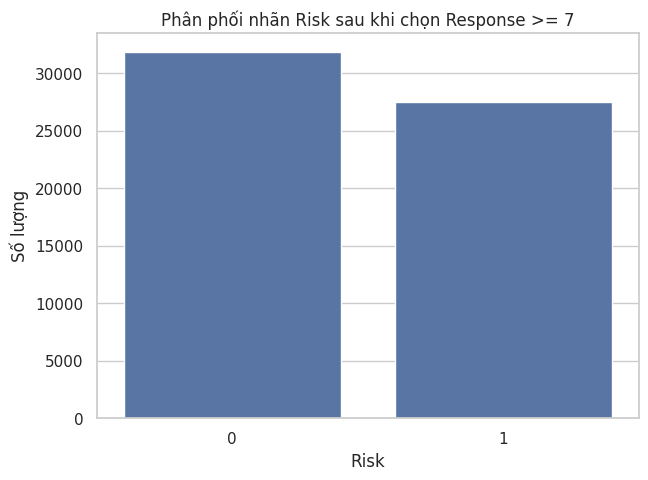

Risk
0    31865
1    27516
Name: count, dtype: int64
Risk
0    0.536619
1    0.463381
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Risk")

plt.title(f"Phân phối nhãn Risk sau khi chọn Response >= {best_threshold}")
plt.xlabel("Risk")
plt.ylabel("Số lượng")
plt.show()

print(df["Risk"].value_counts())
print(df["Risk"].value_counts(normalize=True))

## 5. Tiền xử lý dữ liệu thô và tạo đặc trưng

Một số xử lý chính:

### Tách `Product_Info_2`
Cột `Product_Info_2` có dạng kết hợp chữ và số, ví dụ `A1`, `B2`. Vì vậy tách thành:
- `Product_Info_2_C`: phần chữ.
- `Product_Info_2_N`: phần số.

### Tạo đặc trưng tổng hợp
Tạo thêm các cột tổng hợp như:
- `SumMedicalKeywords`
- `SumEmploymentInfo`
- `SumMedicalHistory`

Các đặc trưng này giúp mô hình nắm được thông tin tổng quát hơn thay vì chỉ dùng từng cột riêng lẻ.

In [ ]:
def preprocess_raw_dataframe(data):
    df_processed = data.copy()

    # Tách cột Product_Info_2 nếu tồn tại
    if 'Product_Info_2' in df_processed.columns:
        df_processed['Product_Info_2_C'] = df_processed['Product_Info_2'].astype(str).str[0]
        df_processed['Product_Info_2_N'] = pd.to_numeric(
            df_processed['Product_Info_2'].astype(str).str[1:],
            errors='coerce'
        )

    # Tạo đặc trưng tổng hợp từ các nhóm cột
    medical_keyword_cols = [c for c in df_processed.columns if c.startswith('Medical_Keyword_')]
    employment_cols = [c for c in df_processed.columns if c.startswith('Employment_Info_')]
    medical_history_cols = [c for c in df_processed.columns if c.startswith('Medical_History_')]

    if len(medical_keyword_cols) > 0:
        df_processed['SumMedicalKeywords'] = df_processed[medical_keyword_cols].sum(axis=1)

    if len(employment_cols) > 0:
        df_processed['SumEmploymentInfo'] = df_processed[employment_cols].sum(axis=1)

    if len(medical_history_cols) > 0:
        df_processed['SumMedicalHistory'] = df_processed[medical_history_cols].sum(axis=1)

    return df_processed

df_processed = preprocess_raw_dataframe(df)

print('Kích thước sau xử lý thô:', df_processed.shape)
df_processed.head()


Kích thước sau xử lý thô: (59381, 134)


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response,Risk,Product_Info_2_C,Product_Info_2_N,SumMedicalKeywords,SumEmploymentInfo,SumMedicalHistory
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,8,1,D,3,0,16.0280,430.0
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,4,0,A,1,0,6.0018,487.0
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,8,1,E,1,0,12.0600,88.0
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,8,1,D,4,1,13.2420,425.0
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,8,1,D,2,0,12.0770,237.0


## 6. Tách biến đầu vào X và nhãn y

Các cột không đưa vào mô hình:
- `Id`: mã định danh, không có ý nghĩa dự đoán.
- `Response`: nhãn gốc, nếu giữ lại sẽ gây rò rỉ dữ liệu.
- `Risk`: nhãn mới cần dự đoán.
- `Product_Info_2`: đã được tách thành hai cột mới.

In [ ]:
drop_cols = ['Id', 'Response', 'Risk', 'Product_Info_2']
drop_cols = [c for c in drop_cols if c in df_processed.columns]

X = df_processed.drop(columns=drop_cols)
y = df_processed['Risk']

print('Số đặc trưng đầu vào:', X.shape[1])
print('Kích thước X:', X.shape)
print('Kích thước y:', y.shape)


Số đặc trưng đầu vào: 130
Kích thước X: (59381, 130)
Kích thước y: (59381,)


## 7. Chia dữ liệu Train/Test theo tỉ lệ 70/30

Dữ liệu được chia thành:
- **70% Train**: dùng để huấn luyện mô hình.
- **30% Test**: dùng để đánh giá mô hình.

Sử dụng `stratify=y` để giữ tỉ lệ lớp 0 và lớp 1 trong hai tập gần giống với dữ liệu ban đầu.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Kích thước tập train:', X_train.shape)
print('Kích thước tập test :', X_test.shape)

print('Tỉ lệ nhãn trong tập train:')
print(y_train.value_counts(normalize=True))

print('Tỉ lệ nhãn trong tập test:')
print(y_test.value_counts(normalize=True))


Kích thước tập train: (41566, 130)
Kích thước tập test : (17815, 130)
Tỉ lệ nhãn trong tập train:
Risk
0    0.536616
1    0.463384
Name: proportion, dtype: float64
Tỉ lệ nhãn trong tập test:
Risk
0    0.536626
1    0.463374
Name: proportion, dtype: float64


## 8. Xây dựng bước tiền xử lý bằng Pipeline

Dữ liệu được chia thành hai nhóm:

### Cột số
- Điền thiếu bằng `median`.
- Chuẩn hóa bằng `StandardScaler`.

Lý do dùng `median`: ít bị ảnh hưởng bởi ngoại lai hơn trung bình.  
Lý do dùng `StandardScaler`: giúp Logistic Regression, SVM và KNN hoạt động ổn định hơn.

### Cột phân loại
- Điền thiếu bằng giá trị xuất hiện nhiều nhất.
- Mã hóa bằng `OneHotEncoder`.

Lý do dùng `handle_unknown='ignore'`: tránh lỗi nếu tập test có giá trị phân loại chưa xuất hiện trong train.


In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Số cột số:', len(numeric_features))
print('Số cột phân loại:', len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Số cột số: 129
Số cột phân loại: 1


## 9. Chọn đặc trưng bằng SelectKBest

Notebook chọn `k = 25` đặc trưng tốt nhất sau tiền xử lý.

Lý do chọn 25 đặc trưng:
- Giúp bài làm gọn, phù hợp môn học máy cơ bản.
- Giảm số chiều dữ liệu.
- Giảm nguy cơ overfitting.
- Mô hình chạy nhanh hơn và dễ giải thích hơn.

Dùng `f_classif` vì đây là bài toán phân loại.


In [ ]:
k_features = 25
feature_selector = SelectKBest(score_func=f_classif, k=k_features)


**10. 4 mô hình**

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,    #mô hình có đủ số lần lặp để học ổn định hơn, tránh lỗi
        class_weight='balanced', #bài toán phân loại rủi ro thường cần tránh mô hình học lệch về lớp đông hơn.
        random_state=RANDOM_STATE #Dùng để cố định kết quả khi chạy lại nhiều lần.
    ),

    #Random Forest là mô hình gồm nhiều cây quyết định. Các siêu tham số ở đây dùng để kiểm soát số lượng cây và độ phức tạp của cây.
    'Random Forest': RandomForestClassifier(
        n_estimators=200,  #mô hình tạo ra 200 cây quyết định, sau đó tổng hợp kết quả của các cây
        max_depth=10,     #mỗi cây chỉ được phát triển tối đa 10 tầng, cây sâu ovf, nông undf
        min_samples_split=10, #nếu một node có ít hơn 10 mẫu thì nó sẽ không được tách nữa
        min_samples_leaf=5,   #mỗi lá cuối cùng phải có ít nhất 5 mẫu.
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    #Linear SVM là mô hình phân loại tuyến tính, tìm một đường hoặc siêu phẳng để tách hai lớp
    'Linear SVM': LinearSVC(
        C=1.0,    #tham số điều chỉnh mức độ phạt khi phân loại sai.
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
#KNN phân loại một mẫu mới dựa trên các mẫu gần nó nhất.
    'KNN': KNeighborsClassifier(
        n_neighbors=5 #mô hình nhìn 5 điểm dữ liệu gần nhất, xem lớp nào xuất hiện nhiều hơn thì dự đoán lớp đó.
    )
}


Các siêu tham số được lựa chọn nhằm tạo ra các mô hình baseline đủ ổn định và hạn chế overfitting. Với Logistic Regression, max_iter=1000 được dùng để đảm bảo mô hình hội tụ. Với Random Forest, các tham số max_depth=10, min_samples_split=10 và min_samples_leaf=5 giúp kiểm soát độ phức tạp của cây, tránh học thuộc dữ liệu. Số lượng cây n_estimators=200 giúp mô hình ổn định hơn. Với Linear SVM, C=1.0 là giá trị cân bằng giữa lỗi huấn luyện và khả năng tổng quát. Với KNN, n_neighbors=5 là lựa chọn phổ biến để giảm nhiễu so với việc chỉ dùng một hàng xóm gần nhất. Ngoài ra, class_weight='balanced' được sử dụng cho các mô hình hỗ trợ tham số này để hạn chế ảnh hưởng của mất cân bằng lớp.

## 11. Huấn luyện và đánh giá mô hình trên tập Test

Các mô hình được huấn luyện trên tập Train 70% và đánh giá trên tập Test 30%.

Các chỉ số đánh giá:
- `Accuracy`: tỉ lệ dự đoán đúng tổng thể.
- `Precision`: trong các mẫu dự đoán là lớp 1, có bao nhiêu mẫu đúng.
- `Recall`: trong các mẫu thực tế là lớp 1, mô hình tìm đúng được bao nhiêu.
- `F1-score`: trung bình điều hòa giữa Precision và Recall.
- `ROC-AUC`: khả năng phân biệt giữa hai lớp.

In [ ]:


def get_model_score_for_auc(model, X_data):
    """Lấy điểm dự đoán để tính ROC-AUC.
    Nếu mô hình có predict_proba thì dùng xác suất lớp 1.
    Nếu không có thì dùng decision_function.
    """
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    elif hasattr(model, 'decision_function'):
        return model.decision_function(X_data)
    else:
        return model.predict(X_data)

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = get_model_score_for_auc(pipeline, X_test)

    trained_models[name] = pipeline

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.798428,0.747506,0.853180,0.796855,0.882326
2,Linear SVM,0.774740,0.725686,0.826166,0.772673,0.853292
0,Logistic Regression,0.774516,0.729379,0.816233,0.770365,0.853474
3,KNN,0.756385,0.723179,0.768383,0.745096,0.823843


Kết quả so sánh cho thấy Random Forest là mô hình có hiệu quả tốt nhất trong bốn mô hình được thử nghiệm. Mô hình đạt Accuracy 79.84%, Precision 74.75%, Recall 85.32%, F1-score 79.69% và ROC-AUC 88.23%. Đặc biệt, Recall của Random Forest cao nhất, cho thấy mô hình có khả năng phát hiện tốt các trường hợp thuộc nhóm rủi ro

## 12. Trực quan hóa kết quả so sánh mô hình


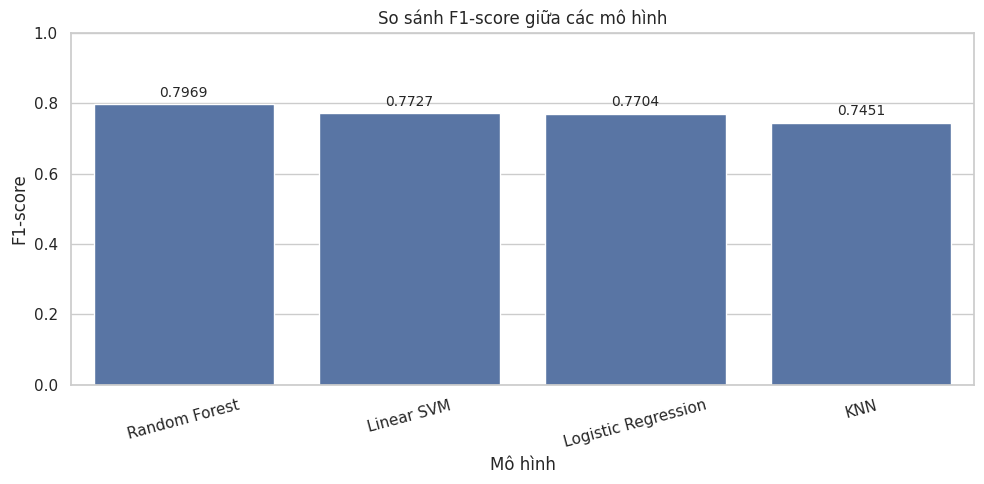

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=results_df,
    x="Model",
    y="F1-score" # F1-score = 2 * Precision * Recall / (Precision + Recall)
)

plt.title("So sánh F1-score giữa các mô hình")
plt.xlabel("Mô hình")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.ylim(0, 1)

# Ghi giá trị lên từng cột
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        fontsize=10,
        padding=3
    )

plt.tight_layout()
plt.show()

Biểu đồ F1-score cho thấy Random Forest đạt kết quả tốt nhất với F1-score = 0.7969. Điều này chứng tỏ mô hình Random Forest có khả năng cân bằng tốt giữa việc dự đoán đúng các trường hợp rủi ro và hạn chế bỏ sót các trường hợp rủi ro. Linear SVM và Logistic Regression có kết quả khá gần nhau, lần lượt đạt 0.7727 và 0.7704. KNN có F1-score thấp nhất là 0.7451, cho thấy mô hình này chưa phù hợp bằng các mô hình còn lại.

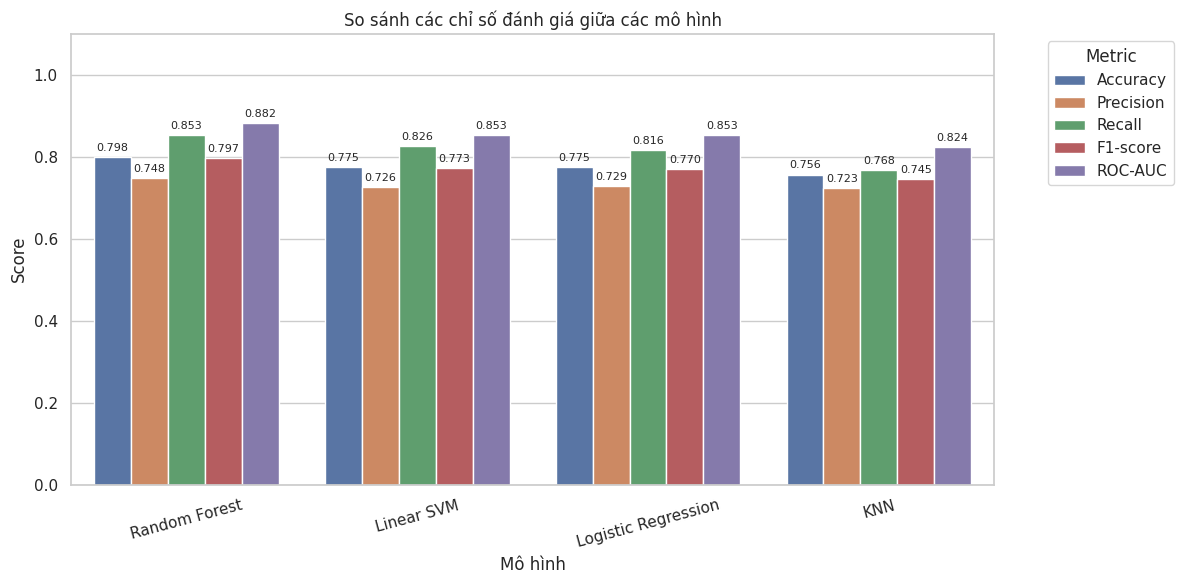

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chuyển bảng kết quả sang dạng dài để vẽ
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("So sánh các chỉ số đánh giá giữa các mô hình")
plt.xlabel("Mô hình")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

# Ghi giá trị lên từng cột
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=3
    )

plt.tight_layout()
plt.show()


Biểu đồ so sánh các chỉ số đánh giá cho thấy Random Forest là mô hình có hiệu quả tốt nhất trong bốn mô hình thử nghiệm. Mô hình này đạt Accuracy 0.798, Precision 0.748, Recall 0.853, F1-score 0.797 và ROC-AUC 0.882. Đặc biệt, Recall và ROC-AUC của Random Forest đều cao nhất, cho thấy mô hình có khả năng phát hiện tốt nhóm rủi ro và phân biệt hai lớp hiệu quả. Linear SVM và Logistic Regression có kết quả khá tương đồng, trong khi KNN cho kết quả thấp nhất

In [ ]:
#chọn ra mô hình tốt nhất
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Mô hình tốt nhất theo F1-score:', best_model_name)

Mô hình tốt nhất theo F1-score: Random Forest


In [ ]:
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=['Risk 0', 'Risk 1']))

              precision    recall  f1-score   support

      Risk 0       0.86      0.75      0.80      9560
      Risk 1       0.75      0.85      0.80      8255

    accuracy                           0.80     17815
   macro avg       0.80      0.80      0.80     17815
weighted avg       0.81      0.80      0.80     17815



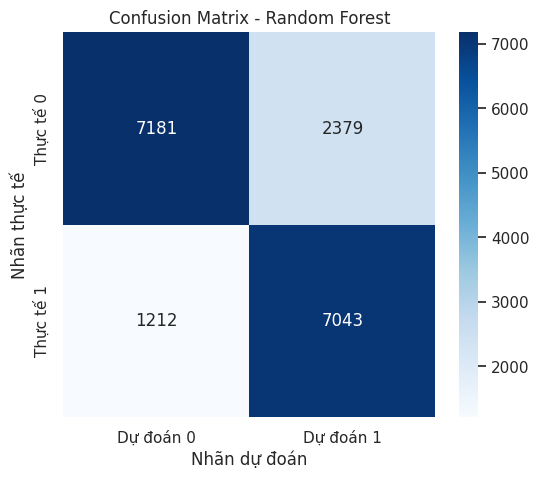

In [ ]:
# vẽ confusion matrix - random forest
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán 0', 'Dự đoán 1'],
            yticklabels=['Thực tế 0', 'Thực tế 1'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.show()


Ma trận nhầm lẫn của mô hình Random Forest cho thấy mô hình dự đoán đúng 7181 mẫu thuộc lớp không rủi ro và 7043 mẫu thuộc lớp rủi ro. Số mẫu rủi ro bị bỏ sót là 1212, trong khi số mẫu không rủi ro bị dự đoán nhầm thành rủi ro là 2379. Kết quả này cho thấy mô hình có xu hướng ưu tiên phát hiện lớp rủi ro, thể hiện qua Recall lớp 1 đạt khoảng 85.32%. Tuy nhiên, vẫn còn một số lượng đáng kể mẫu không rủi ro bị dự đoán nhầm thành rủi ro, nên Precision lớp 1 chỉ đạt khoảng 74.75%

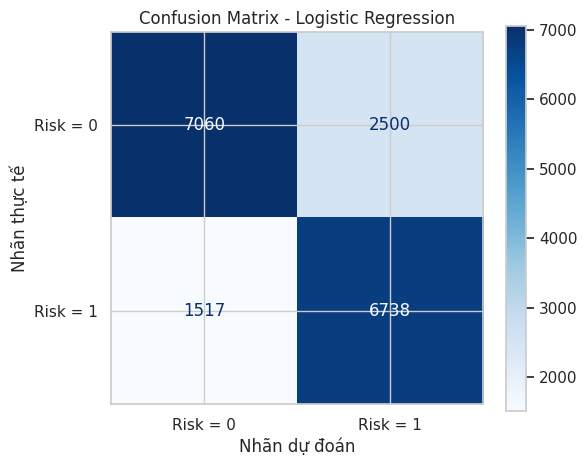

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

    Risk = 0       0.82      0.74      0.78      9560
    Risk = 1       0.73      0.82      0.77      8255

    accuracy                           0.77     17815
   macro avg       0.78      0.78      0.77     17815
weighted avg       0.78      0.77      0.77     17815



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Lấy mô hình Logistic Regression đã train
lr_model = trained_models["Logistic Regression"]

# Dự đoán trên tập test
y_pred_lr = lr_model.predict(X_test)

# Tạo confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Vẽ confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Risk = 0", "Risk = 1"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.show()

# In báo cáo đánh giá
print("Classification Report - Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Risk = 0", "Risk = 1"],
    zero_division=0
))

Ma trận nhầm lẫn của mô hình Logistic Regression cho thấy mô hình dự đoán đúng 7050 mẫu thuộc lớp Risk = 0 và 6738 mẫu thuộc lớp Risk = 1. Tuy nhiên, mô hình vẫn dự đoán nhầm 2500 mẫu Risk = 0 thành Risk = 1 và bỏ sót 1517 mẫu Risk = 1. Kết quả classification report cho thấy mô hình đạt Accuracy khoảng 77%, F1-score trung bình khoảng 0.77. Recall của lớp Risk = 1 đạt 0.82, cho thấy mô hình có khả năng phát hiện tương đối tốt các trường hợp rủi ro. Tuy nhiên, so với Random Forest, Logistic Regression có hiệu quả thấp hơn nên không phải là mô hình tốt nhất trong bài toán này.

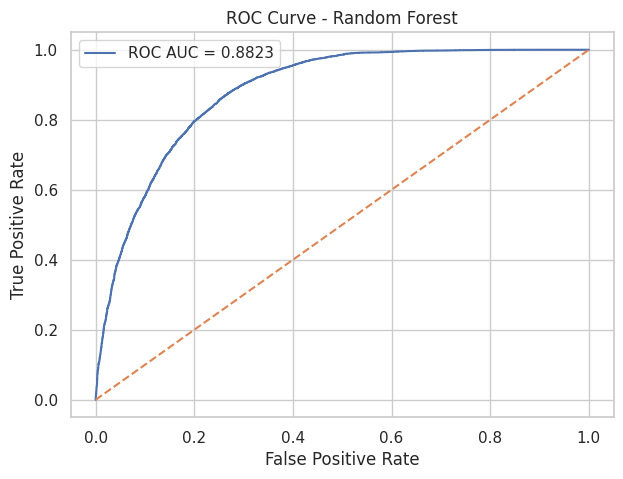

In [ ]:
y_score_best = get_model_score_for_auc(best_model, X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score_best)
auc_value = roc_auc_score(y_test, y_score_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC AUC = {auc_value:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title(f'ROC Curve - {best_model_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Đường ROC của Random Forest nằm cao hơn nhiều so với đường chéo ngẫu nhiên. Giá trị ROC-AUC đạt 0.8823, cho thấy mô hình có khả năng phân biệt tốt giữa hai lớp Risk = 0 và Risk = 1. Đây là kết quả khá tốt đối với bài toán phân loại nhị phân.

Chọn threshold không phải mặc định

In [ ]:
threshold = 0.5

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# Lấy xác suất dự đoán lớp 1 của mô hình tốt nhất
y_score_best = get_model_score_for_auc(best_model, X_test)

threshold_list = np.arange(0.1, 0.91, 0.05) #đánh giá sự thay đổi của Precision, Recall và F1-score, từ đó chọn ngưỡng phù hợp nhất cho bài toán phân loại rủi ro.

threshold_results = []

for th in threshold_list:
    y_pred_th = (y_score_best >= th).astype(int)

    threshold_results.append({
        "Threshold": th,
        "Accuracy": accuracy_score(y_test, y_pred_th),
        "Precision": precision_score(y_test, y_pred_th, zero_division=0),
        "Recall": recall_score(y_test, y_pred_th, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_th, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(by="F1-score", ascending=False).head(10)

,Threshold,Accuracy,Precision,Recall,F1-score
7,0.45,0.795060,0.727246,0.892429,0.801414
6,0.40,0.781757,0.698158,0.931920,0.798277
8,0.50,0.798428,0.747506,0.853180,0.796855
5,0.35,0.766489,0.675978,0.952756,0.790850
9,0.55,0.797755,0.767172,0.809085,0.787571
4,0.30,0.751445,0.656780,0.971048,0.783578
3,0.25,0.737749,0.642307,0.979528,0.775859
10,0.60,0.792534,0.787055,0.757117,0.771796
2,0.20,0.724502,0.629438,0.985827,0.768316
1,0.15,0.700926,0.608818,0.991884,0.754515


Sau khi thử nhiều ngưỡng phân loại khác nhau, threshold = 0.45 cho F1-score cao nhất, đạt 0.8014. So với ngưỡng mặc định 0.50, threshold = 0.45 giúp Recall tăng từ 0.8532 lên 0.8924, tức mô hình phát hiện được nhiều trường hợp rủi ro hơn. Tuy Precision giảm nhẹ từ 0.7475 xuống 0.7272, nhưng F1-score tổng thể tăng từ 0.7969 lên 0.8014. Vì vậy, threshold = 0.45 được xem là ngưỡng phù hợp hơn cho bài toán phân loại rủi ro.

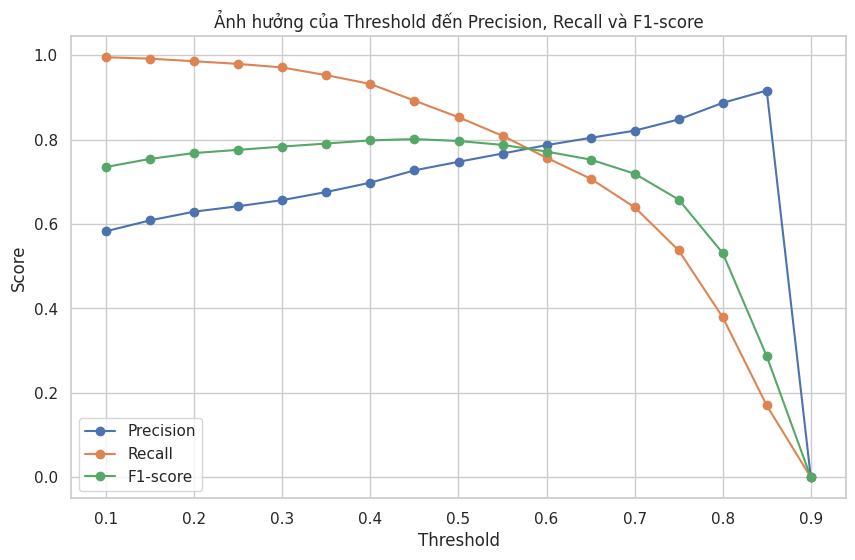

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Ảnh hưởng của Threshold đến Precision, Recall và F1-score")
plt.legend()
plt.grid(True)
plt.show()

Nếu muốn Recall cao hơn → giảm threshold

Nếu muốn Precision cao hơn → tăng threshold

Nếu muốn cân bằng → chọn threshold có F1-score cao nhất

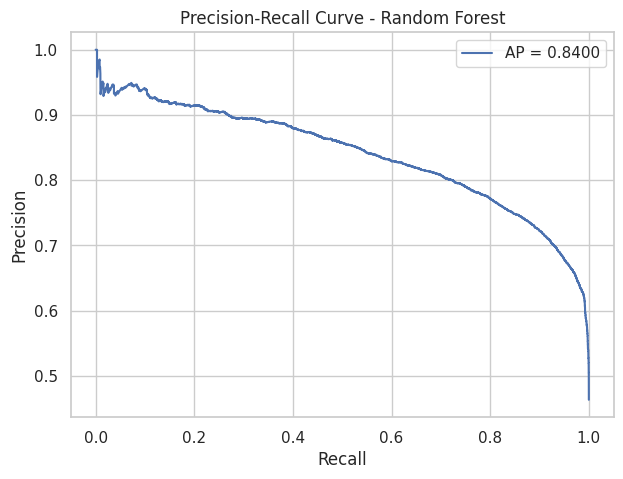

In [ ]:
#Vẽ Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_score_best)
ap_score = average_precision_score(y_test, y_score_best)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()

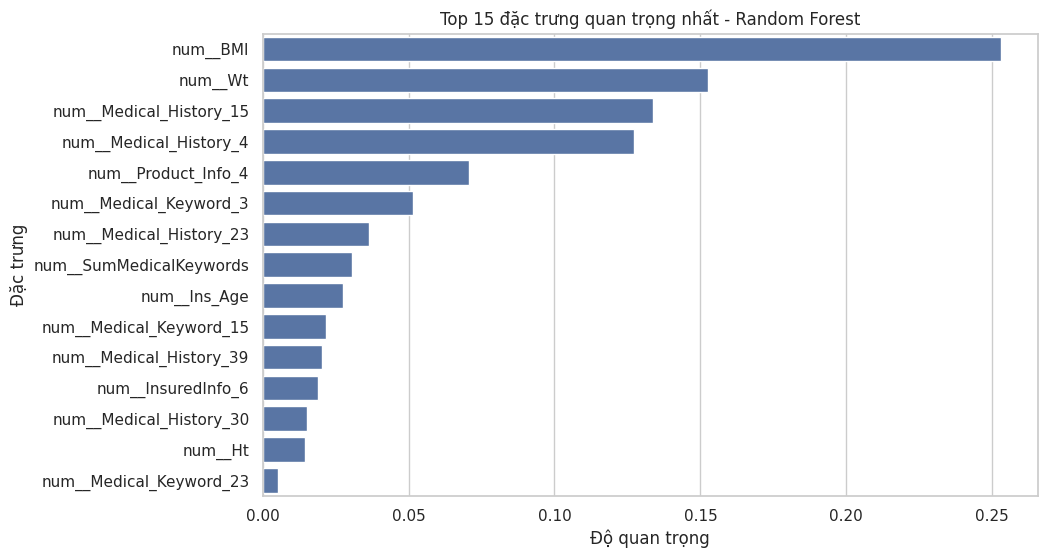

,Feature,Importance
5,num__BMI,0.252881
4,num__Wt,0.152575
12,num__Medical_History_15,0.133604
9,num__Medical_History_4,0.127329
1,num__Product_Info_4,0.070696
19,num__Medical_Keyword_3,0.051419
14,num__Medical_History_23,0.036546
24,num__SumMedicalKeywords,0.030491
2,num__Ins_Age,0.027428
20,num__Medical_Keyword_15,0.021730


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy tên đặc trưng sau tiền xử lý
preprocessor_fitted = best_model.named_steps["preprocessor"]
selector_fitted = best_model.named_steps["selector"]
rf_fitted = best_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
selected_mask = selector_fitted.get_support()
selected_features = feature_names[selected_mask]

importances = rf_fitted.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 đặc trưng quan trọng nhất - Random Forest")
plt.xlabel("Độ quan trọng")
plt.ylabel("Đặc trưng")
plt.show()

feature_importance_df.head(15)